# Fix A — training-free diagnostics

**VoiceLK TTS — Sinhala/English code-switched TTS for G.C.E. O/L ICT content**

This notebook performs the repairs that do **not** touch model weights. Nothing here trains,
fine-tunes or modifies a checkpoint. Existing checkpoints are read only.

## Why this runs before any fine-tuning

`model_evaluate/EVALUATION_REPORT.md` scores two **byte-identical** checkpoints (§1.3 confirms
the MD5 match) at 10.374 dB and 11.101 dB, and quotes 11.91 dB and 10.872 dB for the same
weights elsewhere — a ~1.5 dB spread from one model. Until that spread is removed, a fine-tune
cannot be shown to have worked.

| § | what it does | fixes |
|---|---|---|
| A0 | Environment and path check | — |
| A1 | Transcript ↔ audio alignment audit | the real cause behind §3.7 |
| A2 | Corrected duration statistics | §3.7 counts blanks and diacritics as phonemes |
| A3 | G2P fallthrough audit | §5.4, reordered by severity |
| A4 | Checkpoint footprint | §1.3, §6.3 include the discriminator |
| A5 | Deterministic measurement + noise floor | §3, §4 |
| A6 | `length_scale` sweep | §3.7 length ratio 0.838 |
| A7 | Leak-free test split | §9.1 |

**Environment:** Python 3.11 (`voicelk_ml/venv`). See `README.md` for why not 3.14.

## A0 — Setup and path check

The wav files are **not** in `voicelk_ml/data/wavs`. They sit one level up, next to the repo,
at `<workspace>/data/wavs`. `fa_core` resolves this from the module location, so the notebook
works regardless of the kernel's working directory.

In [ ]:
import sys, platform
from pathlib import Path

# Make the sibling modules importable when the kernel starts elsewhere.
NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / 'fa_core.py').exists() else Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import pandas as pd
import fa_core as fa

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

# Check the kernel BEFORE anything tries to import the vendored Coqui tree.
# A wrong kernel otherwise fails much later with a confusing error — e.g.
# "No module named 'mutagen'" raised from vits_config.py, which says nothing
# about the real cause being the selected interpreter.
env = fa.check_environment()
env

In [ ]:
print('Project root:', fa.PROJECT_ROOT)
print('Wav root    :', fa.WAV_ROOT)
print('Output dir  :', fa.ensure_output_dir())

paths = fa.default_paths()
paths.check()

In [3]:
meta = fa.load_metadata()
print(f'metadata lines : {len(meta)}')
print(f'wavs found     : {meta["wav_exists"].sum()}')
print(f'wavs missing   : {(~meta["wav_exists"]).sum()}')
meta.head(3)[['wav', 'wav_exists', 'ipa']]

metadata lines : 860
wavs found     : 860
wavs missing   : 0


,wav,wav_exists,ipa
0,Download (1).wav,True,meːka d̪annæt̪uʋa lakaːʋeː oneplus dɪˈʋaɪs eka...
1,Download (2).wav,True,sjak ganna kalin menna meː d̪eːʋal gæna d̪ænag...
2,Download (3).wav,True,ˌɪmˈpɔrt karapu eːʋaː neʋeji . eː ʋageːma meːʋ...


## A1 — Transcript ↔ audio alignment audit

The report blames the duration predictor (§3.7). Before accepting that, check whether the
**data** forces the behaviour: a transcript longer than its clip leaves the aligner no choice
but to squeeze every phoneme toward the one-frame minimum.

Speaking rate is measured in **duration-bearing phonemes per second** — whitespace, combining
marks (the dental diacritic in `t̪`) and length/stress marks are excluded, because none of them
occupies time of its own.

Reference points: conversational speech runs ~12–14 phonemes/s, fast speech reaches ~16–18,
and sustained rates above ~22 are not physically plausible.

In [4]:
alignment = fa.audit_alignment(meta)
fa.save(alignment, 'A1_alignment_audit.csv')
fa.alignment_summary(alignment)

,metric,value
0,phonemes_per_sec p10,14.67
1,phonemes_per_sec p25,16.04
2,phonemes_per_sec p50,17.38
3,phonemes_per_sec p75,18.84
4,phonemes_per_sec p90,20.14
5,phonemes_per_sec p99,22.09
6,frames_per_phoneme (median),3.594
7,frames_per_token (median),1.338
8,clip seconds (median),9.82
9,clip seconds (max),10.38


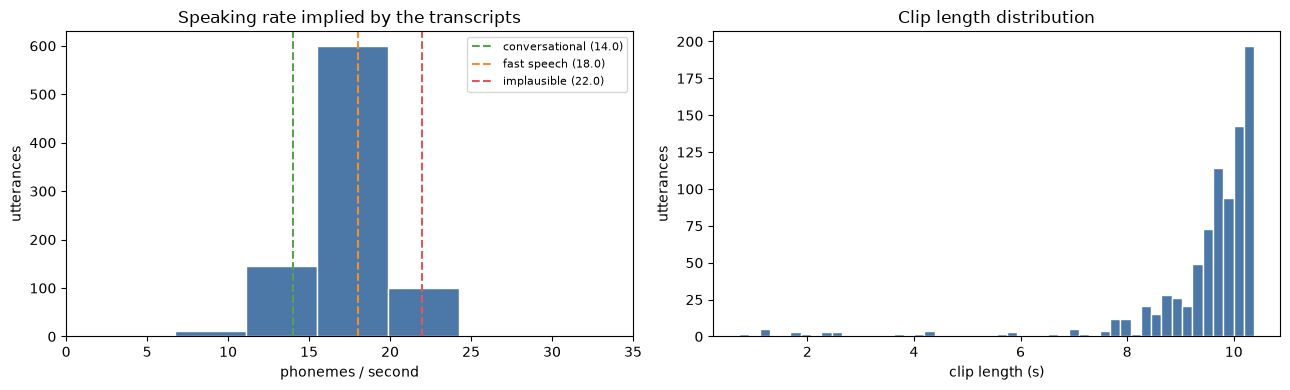

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(alignment['phonemes_per_sec'], bins=50, color='#4C78A8', edgecolor='white')
for x, label, c in [(fa.RATE_COMFORTABLE, 'conversational', '#59A14F'),
                    (fa.RATE_FAST, 'fast speech', '#F28E2B'),
                    (fa.RATE_IMPLAUSIBLE, 'implausible', '#E15759')]:
    axes[0].axvline(x, color=c, linestyle='--', linewidth=1.5, label=f'{label} ({x})')
axes[0].set_xlabel('phonemes / second')
axes[0].set_ylabel('utterances')
axes[0].set_title('Speaking rate implied by the transcripts')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 35)

axes[1].hist(alignment['seconds'], bins=50, color='#4C78A8', edgecolor='white')
axes[1].set_xlabel('clip length (s)')
axes[1].set_ylabel('utterances')
axes[1].set_title('Clip length distribution')

plt.tight_layout()
plt.savefig(fa.ensure_output_dir() / 'A1_alignment.png', dpi=120)
plt.show()

In [6]:
# The clearly broken ones: transcript cannot possibly fit the audio.
broken = alignment[alignment['verdict'] == 'implausible']
print(f'{len(broken)} utterances with an implausible rate ({100*len(broken)/len(alignment):.1f}%)')
broken.head(15)[['wav', 'seconds', 'phonemes', 'phonemes_per_sec', 'verdict']]

10 utterances with an implausible rate (1.2%)


,wav,seconds,phonemes,phonemes_per_sec,verdict
0,Download (691).wav,0.717,159,221.76,implausible
1,Download (857).wav,10.087,246,24.39,implausible
2,Download (321).wav,9.714,222,22.85,implausible
3,Download (163).wav,10.010,227,22.68,implausible
4,Download (58).wav,9.487,215,22.66,implausible
5,Download (505).wav,10.278,232,22.57,implausible
6,Download (536).wav,10.226,229,22.39,implausible
7,Download (533).wav,10.226,228,22.30,implausible
8,Download (336).wav,8.756,194,22.16,implausible
9,Download (335).wav,8.756,193,22.04,implausible


### Read this before moving on

Two separate things show up here.

**1. Clip lengths are capped, not pause-bounded.** If the length histogram piles up just under
a round number with a hard edge, the audio was cut on a fixed timer rather than at silence.
That also explains the mid-word boundaries — `Download (1).wav` ends mid-word and
`Download (2).wav` opens with the remainder. Re-segmentation on VAD fixes this, and it is
*not* a Fix A item.

**2. The corpus genuinely is fast.** A median in the high teens is at the top of the human
range but not impossible for spontaneous YouTube tech commentary. So this audit does **not**
by itself prove the transcripts overrun the audio — it bounds how much of §3.7 the data
explains. The handful of `implausible` rows are real defects; the bulk is fast speech.

## A2 — Corrected duration statistics

§3.7 reports *83% of tokens at the minimum one-frame duration* and concludes the duration
predictor has collapsed. That figure counts tokens, and a token is not a phoneme:

1. `add_blank=True` (the `VitsConfig` default, confirmed in every saved `config.json`)
   interleaves a `<BLNK>` between every character — so ~50% of tokens are blanks that
   **correctly** receive one frame.
2. ~10% of the IPA characters are combining marks and length/stress marks, which have no
   duration of their own.

Together those account for most of the 83%. The cell below recomputes on duration-bearing
phonemes, giving **frames per phoneme**, which can be compared against real speech.

In [7]:
# Expected frames/token, derived from the corpus rather than the model.
med_rate = alignment['phonemes_per_sec'].median()
frames_per_sec = 1 / fa.FRAME_SECONDS

expected_fpp = frames_per_sec / med_rate
chars_per_phoneme = alignment['ipa_chars'].sum() / alignment['phonemes'].sum()
tokens_per_phoneme = 2 * chars_per_phoneme     # add_blank doubles the sequence
expected_fpt = expected_fpp / tokens_per_phoneme

print(f'median corpus rate      : {med_rate:.1f} phonemes/s')
print(f'frames per second       : {frames_per_sec:.1f}')
print(f'-> frames per phoneme   : {expected_fpp:.2f}')
print(f'chars per phoneme       : {chars_per_phoneme:.2f}   (diacritics + spaces)')
print(f'tokens per phoneme      : {tokens_per_phoneme:.2f}   (add_blank)')
print(f'-> frames per TOKEN     : {expected_fpt:.2f}')
print()
print('Report §3.7 measured     : 1.288 (System A) / 1.272 (System B) frames/token')
print()
print('If those two agree, the duration predictor is reproducing its training data')
print('faithfully and has NOT collapsed. The collapse finding is a counting artefact.')

median corpus rate      : 17.4 phonemes/s
frames per second       : 62.5
-> frames per phoneme   : 3.60
chars per phoneme       : 1.34   (diacritics + spaces)
tokens per phoneme      : 2.69   (add_blank)
-> frames per TOKEN     : 1.34

Report §3.7 measured     : 1.288 (System A) / 1.272 (System B) frames/token

If those two agree, the duration predictor is reproducing its training data
faithfully and has NOT collapsed. The collapse finding is a counting artefact.


## A3 — G2P fallthrough audit

When `eng_to_ipa` has no entry for a word it returns the word unchanged, and
`data_preparation/prepare_dataset.py` writes it into the IPA column silently. The model then
learns Latin letters as if they were phonemes — which is where `A B C G H I M P S T` in the
90-symbol vocabulary came from.

These are worth more than the frequency-ordered OOV list in §10.5: an OOV word merely has a
*guessed* pronunciation, while these have **none at all**.

In [8]:
fallthrough = fa.audit_g2p_fallthrough(meta)
fa.save(fallthrough, 'A3_g2p_fallthrough.csv')

print(f'{len(fallthrough)} distinct words, {fallthrough["count"].sum()} instances')
print('-> add these to model_engine/lexicon.json (en_lexicon), highest count first')
fallthrough.head(25)

144 distinct words, 306 instances
-> add these to model_engine/lexicon.json (en_lexicon), highest count first


,word,count,example_wav
0,Lenovo,12,Download (190).wav
1,ChatGPT,11,Download (162).wav
2,OnePlus,10,Download (1).wav
3,Hz,10,Download (88).wav
4,TikTok,7,Download (71).wav
5,WhatsApp,7,Download (21).wav
6,Ryzen,6,Download (187).wav
7,Blackview,5,Download (86).wav
8,backlit,5,Download (190).wav
9,soundbar,5,Download (703).wav


In [9]:
# Starter block for lexicon.json — fill in the 'ipa' values by hand.
import json

stub = {row.word.lower(): {'ipa': '', 'read_as': 'word', 'source': 'A3_g2p_fallthrough'}
        for row in fallthrough.head(50).itertuples()}

stub_path = fa.ensure_output_dir() / 'A3_lexicon_stub.json'
stub_path.write_text(json.dumps(stub, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'wrote {len(stub)} stub entries -> {stub_path}')
print('Fill the ipa fields, then merge into model_engine/lexicon.json')

wrote 50 stub entries -> D:\RUSL\Final Project\TTS\voicelk_ml\model_finetune\outputs\A3_lexicon_stub.json
Fill the ipa fields, then merge into model_engine/lexicon.json


## A4 — Checkpoint footprint, discriminator excluded

§1.3 and §6.3 quote *weights only, fp32 = 316.8 MB*. That figure includes the discriminator,
which exists only for adversarial training and is never loaded at synthesis time.

In [10]:
import fa_inference as fi

runs = fi.available_runs()
runs

,run,sample_rate,n_checkpoints,checkpoints
0,custom,16000,5,"best_model.pth, best_model_63079.pth, checkpoi..."
1,voicelk_vits_custom-September-08-2026_05+59AM-...,16000,6,"best_model_51837.pth, best_model_63079.pth, ch..."
2,voicelk_vits_pathnirwana-September-04-2026_07+...,22050,14,"best_model.pth, best_model_115171.pth, best_mo..."


In [11]:
RUN = fa.MODEL_DIR / 'custom'
CHECKPOINT = RUN / 'best_model.pth'

footprint = fa.audit_footprint(CHECKPOINT)
fa.save(footprint, 'A4_footprint.csv')
display(footprint)
fa.footprint_summary(footprint)

,module,parameters,share_%,fp32_MB,deployed
0,disc,46747132,56.29,178.3,False
1,waveform_decoder,14337024,17.26,54.7,True
2,posterior_encoder,7238016,8.72,27.6,True
3,flow,7102080,8.55,27.1,True
4,text_encoder,6309888,7.60,24.1,True
5,duration_predictor,1317168,1.59,5.0,True


,quantity,value
0,total parameters in checkpoint,"83,051,308"
1,training-only (discriminator),"46,747,132"
2,deployable parameters,"36,304,176"
3,deployable fp32,138.5 MB
4,deployable fp16,69.2 MB


## A5 — Deterministic measurement and the noise floor

This is the section that makes every other number trustworthy.

VITS synthesis is stochastic: `inference_noise_scale = 0.667`, `noise_scale_dp = 1.0`, and the
evaluation notebook seeds neither. Setting `noise_scale_dp = 0` fixes the duration predictor —
the largest variance source — and seeding fixes the rest.

**The noise floor is the number to remember.** Any improvement smaller than the spread below
is not an improvement. Run this again after the fine-tune and compare like for like.

In [12]:
loaded = fi.load_model(RUN, 'best_model.pth')
print(f'loaded    : {loaded.name} / {loaded.checkpoint.name}')
print(f'sample rate: {loaded.sample_rate}')
print(f'vocab size : {loaded.tokenizer.characters.num_chars}')

ModuleNotFoundError: No module named 'mutagen'

In [ ]:
# Reference pairs must come from the HELD-OUT side, or the baseline measures
# memorisation rather than performance. §3.2 shows how large the difference is:
# training-split MCD is 7.4-8.2 dB against 10.9-11.3 dB held out.
#
# Increase N_PAIRS once the timing is known — CPU synthesis runs at roughly
# 0.4x real time, so 10 pairs x 5 repeats takes a few minutes.
N_PAIRS = 10

held_out = fa.build_test_split(alignment, fraction=0.05)
held_out = held_out[held_out['split'] == 'test']['wav'].tolist()

pairs = meta[meta['wav'].isin(held_out[:N_PAIRS])][['wav', 'wav_path', 'ipa']].copy()
print(f'{len(pairs)} held-out reference pairs (of {len(held_out)} available)')
pairs[['wav']].head()

In [ ]:
measurements = fi.measure_noise_floor(loaded, pairs, n_repeats=fa.N_REPEATS)
fa.save(measurements, 'A5_noise_floor.csv')

summary = fi.noise_floor_summary(measurements)
display(summary)

print(f"MCD mean        : {measurements['mcd_db'].mean():.3f} dB")
print(f"Worst per-utterance spread : {summary['spread'].max():.3f} dB")
print(f"Mean length ratio          : {measurements['length_ratio'].mean():.3f}")
print()
print('=> Treat any MCD change smaller than the worst spread as noise.')

In [ ]:
# Compare against the stochastic setting the report used, to show what the
# seeding actually bought.
stochastic = fi.measure_noise_floor(loaded, pairs.head(3), n_repeats=fa.N_REPEATS,
                                    deterministic_duration=False)
det = measurements[measurements['wav'].isin(stochastic['wav'].unique())]

comparison = pd.DataFrame([
    {'mode': 'stochastic (as in the report)',
     'mcd_std': round(stochastic.groupby('wav')['mcd_db'].std().mean(), 3),
     'length_ratio_std': round(stochastic.groupby('wav')['length_ratio'].std().mean(), 4)},
    {'mode': 'deterministic durations',
     'mcd_std': round(det.groupby('wav')['mcd_db'].std().mean(), 3),
     'length_ratio_std': round(det.groupby('wav')['length_ratio'].std().mean(), 4)},
])
fa.save(comparison, 'A5_determinism_gain.csv')
comparison

## A6 — `length_scale` sweep

§3.7 reports a length ratio of 0.838: the synthesis is ~16% shorter than the recording.
`length_scale` is an inference-time multiplier on predicted durations, so part of this is
recoverable without touching a weight.

This changes rate **uniformly**, so it cannot restore rhythm the duration predictor never
learned. It is a partial remedy, and it is free.

In [ ]:
sweep = fi.length_scale_sweep(loaded, pairs.head(5))
fa.save(sweep, 'A6_length_scale_sweep.csv')
display(sweep)

best = sweep.iloc[(sweep['mean_length_ratio'] - 1.0).abs().argmin()]
print(f"length_scale closest to ratio 1.0 : {best['length_scale']} "
      f"(ratio {best['mean_length_ratio']}, MCD {best['mean_mcd_db']} dB)")
print('Set this in the serving path, then confirm by ear before shipping.')

## A7 — Leak-free test split

`eval_split_size = 0.01` leaves 8 held-out utterances, of which 2 are usable — every
reference-based number in §3 rests on n=2.

Raising the fraction is not enough on its own. Once the corpus is re-segmented, clips cut from
one recording are highly correlated, so a **random** split leaks training audio into the test
set. Whole sources have to be held out instead.

The current filenames (`Download (N).wav`) carry no recoverable source id, so each clip is its
own group for now. Re-segmentation should name clips `<source>_<index>.wav`, after which
`fa_core.source_id` groups them correctly with no further change.

In [ ]:
split = fa.build_test_split(alignment, fraction=0.05)
fa.save(split, 'A7_test_split.csv')

print(split['split'].value_counts().to_string())
print(f"\ndistinct sources : {split['source'].nunique()}")
print(f"held-out sources : {split[split['split'] == 'test']['source'].nunique()}")
print('\nNOTE: with no source ids yet, this is still a random clip split.')
print('It becomes leak-free automatically once re-segmentation names the clips.')

## Summary — what Fix A established

Run the cell below once everything above has executed.

In [ ]:
rows = [
    ('utterances audited', len(alignment)),
    ('median phonemes/sec', round(alignment['phonemes_per_sec'].median(), 1)),
    ('implausible-rate clips', int((alignment['verdict'] == 'implausible').sum())),
    ('median clip seconds', round(alignment['seconds'].median(), 2)),
    ('max clip seconds', round(alignment['seconds'].max(), 2)),
    ('G2P fallthrough words', len(fallthrough)),
    ('G2P fallthrough instances', int(fallthrough['count'].sum())),
    ('deployable parameters', f"{footprint[footprint['deployed']]['parameters'].sum():,}"),
    ('deployable fp32 MB', round(footprint[footprint['deployed']]['fp32_MB'].sum(), 1)),
    ('MCD mean (deterministic)', round(measurements['mcd_db'].mean(), 3)),
    ('MCD noise floor (worst spread)', round(summary['spread'].max(), 3)),
    ('mean length ratio', round(measurements['length_ratio'].mean(), 3)),
]
baseline = pd.DataFrame(rows, columns=['quantity', 'value'])
fa.save(baseline, 'A_baseline_summary.csv')
baseline

### Next

1. Fill the IPA values in `outputs/A3_lexicon_stub.json` and merge into `model_engine/lexicon.json`.
2. Apply the `length_scale` from A6 in the serving path.
3. Patch `api/main.py` to reject text that produces no phonemes (whitespace, emoji) instead of
   synthesising 0.1 s of noise — see §6.2 of the report.
4. Keep `outputs/A_baseline_summary.csv`. **This is the baseline the fine-tune is measured against.**

Fix A does not improve audio quality. It makes the improvement measurable.